# Analyzing the Autism Prevalence

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from datetime import datetime

Read csv files to Dataframe

In [4]:
# Read Prevalence Estimates by Gender
gender = pd.read_csv("../data/Prevalence Estimates by Sex.csv")
gender.head()

,Year,State,Boys,Boys Lower CI,Boys Upper CI,Girls,Girls Lower CI,Girls Upper CI
0,2000,Alabama,NaN,NaN,NaN,NaN,NaN,NaN
1,2000,Arizona,9.7,8.5,11.1,3.2,2.5,4.0
2,2000,Arkansas,NaN,NaN,NaN,NaN,NaN,NaN
3,2000,California,NaN,NaN,NaN,NaN,NaN,NaN
4,2000,Colorado,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
gender_year = gender.groupby('Year')[['Boys', 'Girls']].mean().reset_index()
gender_year

,Year,Boys,Girls
0,2000,10.000000,2.900000
1,2002,10.533333,2.500000
2,2004,12.544444,2.888889
3,2006,14.175000,3.125000
4,2008,20.226667,4.506667
5,2010,23.541667,5.283333
6,2012,23.675000,5.341667
7,2014,27.666667,6.808333
8,2016,30.125000,7.150000
9,2018,38.100000,9.083333


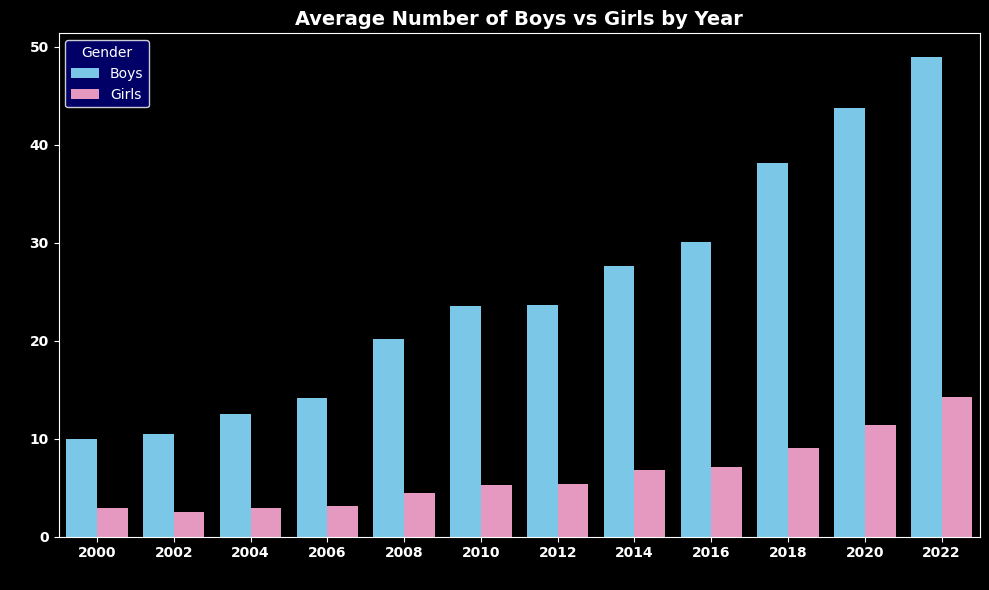

In [62]:
plt.figure(figsize=(10, 6), facecolor="black")

# Melt for easier plotting
gender_melt = gender_year.melt(id_vars="Year", value_vars=["Boys", "Girls"],
                           var_name="Gender", value_name="Count")

# Custom palette
palette = {
    "Boys": "#68CEFA",
    "Girls": "#F28CC0"
}

sns.barplot(
    data=df_melt,
    x="Year",
    y="Count",
    hue="Gender",
    palette=palette
)

# Title
plt.title(
    "Average Number of Boys vs Girls by Year",
    fontsize=14,
    fontweight="bold",
    color="white"
)

# Axes styling
ax = plt.gca()
ax.set_facecolor("black")

# Tick labels
ax.tick_params(axis='x', colors='white', labelsize=10)
ax.tick_params(axis='y', colors='white', labelsize=10)

for tick in ax.get_xticklabels():
    tick.set_color("white")
    tick.set_fontweight("bold")

for tick in ax.get_yticklabels():
    tick.set_color("white")
    tick.set_fontweight("bold")

# Spines
for spine in ax.spines.values():
    spine.set_color("white")

# Make legend title white
leg = plt.legend(title="Gender",facecolor="navy", edgecolor="white", labelcolor="white")
plt.setp(leg.get_title(), color="white")

plt.tight_layout()
plt.savefig("cases_gender", dpi=300, bbox_inches="tight", transparent=True)
plt.show()